In [1]:
pip install pandas numpy matplotlib seaborn fitparse requests

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


# Summer 2019 Personal Fitness Data Report

## 1. Introduction

### 1.1. Dataset

In this report, we are working with a client's fitness data, collected from multiple devices, and multiple workout types, from Jul 8th to Oct 3rd, 2019. The dataset has over 40,000 rows of data. Beyond basic session metadata, the dataset provides continuous heart rate, and 3D spatial coordinates (latitude, longitude, and enhanced barometric altitude).

In this GitHub repository, you can find the complete dataset as below:

- **`strava.csv`**: The primary dataset containing compiled workout data from all devices.
- **`extra.tar.gz`**: The compressed file containing raw, multi-sensor `.fit` activity logs exported from wearable hardware.
- **`extra_data/extra`**: The extracted directory containing high-precision raw data streams.

From this dataset, we will take a look at our client's workout habits, and investigate what factors might help elevate our client's heart rate during workout. Acording to [American Heart Association](https://www.heart.org/en/healthy-living/ exercise-and-physical-activity/fitness-basics/aha-recs-for-physical-activity-in-adults), elevating your heart rate to the targeted zone during workout, and accumulating enough weekly minutes of workout at moderate and vigorous level can help you hink, feel and sleep better and perform daily tasks more easily. Hence, we are interested in workout metrics such as duration and heart rate. 

### 1.2. Reflection on Rule et al's ten rules for computational analyses

In this mini-project, we follow most of Rule et al's ten rules of writing and sharing Jupyter Notebook. Here's how:

- Rule 1: **Tell a story for an audience** Closely followed. We begin the notebook with an introduction of our topic, our dataset, and what we are looking for. Followed with our steps description: what we did, why we did it, and how steps are connected. The ending sections are for interpreting the results and proposed next steps.
- Rule 2: **Document the process, not just the results** Followed. We push various commit to GitHub main branch along the way. Markdown cells and comments are added along the way to keep track of our intention and thought process.
- Rule 3: **Use cell divisions to make steps clear** Followed. Before a block of code, there is usually a markdown cell explaining what the code is for, what it is doing, or what it is aiming to. If needed, we also add another markdown cell following that code to explain what the code's output means.
- Rule 4: **Modularize code** Not followed. This is our favorite rule. However, we do not re-use code that much in this notebook. Our code is not too long either. Hence, only a couple of functions are created.
- Rule 5: **Record dependencies** Followed. At the top of this notebook, you will find a pip install command that includes the libraries and modules you need to run this notebook.
- Rule 6: **Use version control** Partially followed. We push commits to GitHub main branch, but we do not convert to .py before committing changes.
- Rule 7: **Build a pipeline** Followed. We have to restart kernel and re-run all cells frequently to make sure the dataframes stay the way we want them to be. Especially when we repeatedly update their columns' values. The key variable, which is our main dataframe df, is declared near the top of the notebook.
- Rule 8: **Share and explain your data** Followed. We make all the dataset public for this mini-project, along with our notebook.
- Rule 9: **Design your notebook to be read, run, and explored** Partially followed. Since the whole repository is public, anyone can read, run, or fork it. However, we do not go to open source license to grant permission, or use Nbviewer, Binder, Docker, ipywidgets... to offer further options to future users.
- Rule 10: **Advocate for open research** Not followed. Due to the limit scope of this mini-project, we did not ask others to read, run, or explore this notebook before making it public.

## 2. Data import and preparation

### 2.1. Main data file: import and first look

In this section, we will import our main data file `strava.csv`. We will only take a quick look at this data file and then explore the extra data, before performing further data preparation.

First, let's import Python libraries necessary for our data analysics.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Now we have our library. Let's import our file and take a look.

In [4]:
df = pd.read_csv('strava.csv')
pd.set_option('display.max_columns', None)
df.head()

,Air Power,Cadence,Form Power,Ground Time,Leg Spring Stiffness,Power,Vertical Oscillation,altitude,cadence,datafile,distance,enhanced_altitude,enhanced_speed,fractional_cadence,heart_rate,position_lat,position_long,speed,timestamp,unknown_87,unknown_88,unknown_90
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,activities/2675855419.fit.gz,0.00,NaN,0.000,0.0,68.0,NaN,NaN,0.0,2019-07-08 21:04:03,0.0,300.0,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,activities/2675855419.fit.gz,0.00,NaN,0.000,0.0,68.0,NaN,NaN,0.0,2019-07-08 21:04:04,0.0,300.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.0,activities/2675855419.fit.gz,1.32,NaN,1.316,0.0,71.0,NaN,NaN,1316.0,2019-07-08 21:04:07,0.0,300.0,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3747.0,77.0,activities/2675855419.fit.gz,12.19,249.4,1.866,0.0,77.0,504432050.0,-999063637.0,1866.0,2019-07-08 21:04:14,0.0,100.0,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3798.0,77.0,activities/2675855419.fit.gz,14.08,259.6,1.894,0.0,80.0,504432492.0,-999064534.0,1894.0,2019-07-08 21:04:15,0.0,100.0,NaN


That's a lot of missing values. We will look into them later. Now let's see what info this dataset has to offer.

In [5]:
df.columns

Index(['Air Power', 'Cadence', 'Form Power', 'Ground Time',
       'Leg Spring Stiffness', 'Power', 'Vertical Oscillation', 'altitude',
       'cadence', 'datafile', 'distance', 'enhanced_altitude',
       'enhanced_speed', 'fractional_cadence', 'heart_rate', 'position_lat',
       'position_long', 'speed', 'timestamp', 'unknown_87', 'unknown_88',
       'unknown_90'],
      dtype='str')

There're a lot of insights we can explore with these values. In this notebook, we are interested in:
- 'timestamp': necessary to analyze workout habits and durations
- 'heart_rate': important workout metric
- 'cadence' and 'Cadence': related to movement frequency recorded during workout
- 'altitude', 'enhanced_altitude', 'position_lat', 'position_long': spatial coordinates recorded during workout

We will further perform data cleaning and preparation for these values in later sections.

For now, let's take a look at the range of our data:

In [6]:
df.describe()

,Air Power,Cadence,Form Power,Ground Time,Leg Spring Stiffness,Power,Vertical Oscillation,altitude,cadence,distance,enhanced_altitude,enhanced_speed,fractional_cadence,heart_rate,position_lat,position_long,speed,unknown_87,unknown_88,unknown_90
count,17842.000000,17847.000000,17842.000000,17847.000000,17842.000000,17847.000000,17847.000000,14905.000000,40627.000000,40649.000000,40598.000000,40639.000000,40627.000000,38355.000000,4.045700e+04,4.045700e+04,14928.000000,40627.0,38355.000000,18618.000000
mean,1.872100,77.726565,99.485932,325.934107,13.138571,301.459797,6.458074,3846.184368,72.781254,4097.140051,271.346027,3.037084,0.070138,134.680094,5.045408e+08,-9.995175e+08,2067.483856,0.0,298.513883,-1.067354
std,2.777476,9.202077,13.866222,71.773687,2.039567,48.540552,1.135497,134.262498,17.743728,5827.964663,25.035768,1.959805,0.173639,18.713782,1.690905e+05,1.376341e+06,527.173476,0.0,17.176218,2.820492
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3555.000000,0.000000,0.000000,209.000000,0.000000,0.000000,56.000000,5.039868e+08,-1.005696e+09,0.000000,0.0,100.000000,-13.000000
25%,1.000000,78.000000,97.000000,308.000000,13.000000,283.000000,6.125000,3768.000000,74.000000,1117.970000,252.800000,2.109000,0.000000,121.000000,5.044397e+08,-9.993986e+08,1782.000000,0.0,300.000000,-3.000000
50%,1.000000,79.000000,101.000000,326.000000,13.375000,303.000000,6.500000,3829.000000,78.000000,2430.500000,269.200000,2.445000,0.000000,136.000000,5.045116e+08,-9.992608e+08,2071.000000,0.0,300.000000,0.000000
75%,2.000000,80.000000,105.000000,340.000000,13.750000,326.000000,7.000000,3912.000000,80.000000,4403.730000,291.200000,2.809000,0.000000,148.000000,5.046159e+08,-9.990579e+08,2370.000000,0.0,300.000000,0.000000
max,48.000000,88.000000,125.000000,1732.000000,16.875000,462.000000,12.500000,5043.000000,118.000000,39007.120000,508.600000,15.349000,0.500000,183.000000,5.089272e+08,-9.921938e+08,7744.000000,0.0,300.000000,6.000000


Nothing raises immediate questions. How about data type of each column?

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40649 entries, 0 to 40648
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Air Power             17842 non-null  float64
 1   Cadence               17847 non-null  float64
 2   Form Power            17842 non-null  float64
 3   Ground Time           17847 non-null  float64
 4   Leg Spring Stiffness  17842 non-null  float64
 5   Power                 17847 non-null  float64
 6   Vertical Oscillation  17847 non-null  float64
 7   altitude              14905 non-null  float64
 8   cadence               40627 non-null  float64
 9   datafile              40649 non-null  str    
 10  distance              40649 non-null  float64
 11  enhanced_altitude     40598 non-null  float64
 12  enhanced_speed        40639 non-null  float64
 13  fractional_cadence    40627 non-null  float64
 14  heart_rate            38355 non-null  float64
 15  position_lat          40457 no

We notice that timestamp is in string. Let's create another timestamp_dt column in datetime type for our later analysis:

In [8]:
df['timestamp_dt'] = pd.to_datetime(df['timestamp'], unit='s')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40649 entries, 0 to 40648
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Air Power             17842 non-null  float64       
 1   Cadence               17847 non-null  float64       
 2   Form Power            17842 non-null  float64       
 3   Ground Time           17847 non-null  float64       
 4   Leg Spring Stiffness  17842 non-null  float64       
 5   Power                 17847 non-null  float64       
 6   Vertical Oscillation  17847 non-null  float64       
 7   altitude              14905 non-null  float64       
 8   cadence               40627 non-null  float64       
 9   datafile              40649 non-null  str           
 10  distance              40649 non-null  float64       
 11  enhanced_altitude     40598 non-null  float64       
 12  enhanced_speed        40639 non-null  float64       
 13  fractional_cadence    40627

Let's check our extra data.

### 2.2. Extra data exploration

In [10]:
# access extra data in .tar.gz folder
import io
import requests
import tarfile

url = "https://github.com/vandao288/strava_data_report/raw/main/extra.tar.gz"

response = requests.get(url)
# Open the downloaded stream as a gzipped tar archive ('r:gz')
with tarfile.open(fileobj=io.BytesIO(response.content), mode="r:gz") as tar:
    # List all file names in the archive
    #print(tar.getnames())
    file_paths = tar.getnames()
    print(file_paths)
    # Extract to a local directory
    tar.extractall("./extra_data")

['extra', 'extra/2688518063.fit', 'extra/2694503189.fit', 'extra/2878165145.fit', 'extra/2934415201.fit', 'extra/2875543445.fit', 'extra/4202632408.fit', 'extra/4431076868.fit', 'extra/3220821481.fit', 'extra/2677659014.fit', 'extra/2737470737.fit', 'extra/3037049993.fit', 'extra/2725350599.fit', 'extra/4262319929.fit', 'extra/4233198342.fit', 'extra/2939549086.fit', 'extra/2694503073.fit', 'extra/4449332433.fit', 'extra/2749660320.fit', 'extra/3276319440.fit', 'extra/3573233193.fit', 'extra/4116838134.fit', 'extra/2791022871.fit', 'extra/4116832581.fit', 'extra/2700298434.fit', 'extra/2796808375.fit', 'extra/4182662451.fit', 'extra/2711850942.fit', 'extra/4223086640.fit', 'extra/2912139332.fit', 'extra/3589053594.fit', 'extra/2829934608.fit', 'extra/3094198881.fit', 'extra/3747633909.fit', 'extra/3744072620.fit', 'extra/4380955548.fit', 'extra/4171121567.fit', 'extra/2749724556.fit', 'extra/4151263436.fit', 'extra/3964368444.fit', 'extra/3456057777.fit', 'extra/3790627836.fit', 'extra

In [11]:
len(file_paths)

200

In [12]:
# try to look into fit file in extra data
from fitparse import FitFile

fit_file_path = './extra_data/extra/2688518063.fit'
fitfile = FitFile(fit_file_path)
my_data = fitfile.get_messages('record')

In [13]:
type(my_data)

generator

In [14]:
first_record = next(fitfile.get_messages("record"))

for data in first_record:
    print(data)
    #print(f"Field: {data.name} | Value: {data.value} | Units: {data.units}")

altitude: 258.0 [m]
cadence: 74 [rpm]
distance: 1.27 [m]
enhanced_altitude: 258.0 [m]
enhanced_speed: 1.885 [m/s]
fractional_cadence: 0.5 [rpm]
heart_rate: 103 [bpm]
position_lat: 504427594 [semicircles]
position_long: -998947981 [semicircles]
speed: 1.885 [m/s]
timestamp: 2019-07-14 17:20:28
unknown_87: 0
unknown_88: 300


In [15]:
file0 = file_paths[1]
full_file_path = f'./extra_data/{file0}'
fitfile = FitFile(full_file_path)
records = fitfile.get_messages('record')
for record in records:
    for data in record:
        print(data)

altitude: 258.0 [m]
cadence: 74 [rpm]
distance: 1.27 [m]
enhanced_altitude: 258.0 [m]
enhanced_speed: 1.885 [m/s]
fractional_cadence: 0.5 [rpm]
heart_rate: 103 [bpm]
position_lat: 504427594 [semicircles]
position_long: -998947981 [semicircles]
speed: 1.885 [m/s]
timestamp: 2019-07-14 17:20:28
unknown_87: 0
unknown_88: 300
altitude: 257.79999999999995 [m]
cadence: 74 [rpm]
distance: 2.21 [m]
enhanced_altitude: 257.79999999999995 [m]
enhanced_speed: 1.959 [m/s]
fractional_cadence: 0.5 [rpm]
heart_rate: 104 [bpm]
position_lat: 504427557 [semicircles]
position_long: -998947840 [semicircles]
speed: 1.959 [m/s]
timestamp: 2019-07-14 17:20:29
unknown_87: 0
unknown_88: 300
altitude: 257.4 [m]
cadence: 74 [rpm]
distance: 3.5 [m]
enhanced_altitude: 257.4 [m]
enhanced_speed: 1.81 [m/s]
fractional_cadence: 0.5 [rpm]
heart_rate: 104 [bpm]
position_lat: 504427501 [semicircles]
position_long: -998947669 [semicircles]
speed: 1.81 [m/s]
timestamp: 2019-07-14 17:20:30
unknown_87: 0
unknown_88: 300
altit

In [16]:
i = 0
for file in file_paths:
    if file.endswith('.fit'):
        i += 1
print(f"Number of .fit files: {i}")

Number of .fit files: 199


All files are .fit files.

data_dict = {}
for path in file_paths[1:]:
    full_file_path = f'./extra_data/{path}'
    fitfile = FitFile(full_file_path)
    records = fitfile.get_messages('record')
    for record in records:
        for data in record:
            if data.name not in data_dict:
                data_dict[data.name] = []
            data_dict[data.name].append(data.value)

fitdf = pd.DataFrame(data_dict)
fitdf.sample(5)

In [17]:
# previous student work
def get_data_plus_units(messages):
    data_record = []
    for record in messages:
        record_datum = {}
        for record_data in record:
            if record_data.units:
                record_datum[record_data.name] = str(record_data.value) + ' ' + str(record_data.units)
            else:
                record_datum[record_data.name] = str(record_data.value) + ' unknown'
            data_record.append(record_datum)
    return data_record

In [18]:
#fitdf1 = pd.DataFrame(get_data_plus_units(stryd))
#fitdf2 = pd.DataFrame(get_data_plus_units(my_data))

In [19]:
df.isna().sum()

Air Power               22807
Cadence                 22802
Form Power              22807
Ground Time             22802
Leg Spring Stiffness    22807
Power                   22802
Vertical Oscillation    22802
altitude                25744
cadence                    22
datafile                    0
distance                    0
enhanced_altitude          51
enhanced_speed             10
fractional_cadence         22
heart_rate               2294
position_lat              192
position_long             192
speed                   25721
timestamp                   0
unknown_87                 22
unknown_88               2294
unknown_90              22031
timestamp_dt                0
dtype: int64

In [20]:
df.shape

(40649, 23)

In [21]:
both_present = df['cadence'].notna() & df['Cadence'].notna()
print("Rows with BOTH cadence values present:", both_present.sum())

Rows with BOTH cadence values present: 17847


In [22]:
both_missing = df['cadence'].isna() & df['Cadence'].isna()
print("Rows where BOTH are NA:", both_missing.sum())

Rows where BOTH are NA: 22


- cadence: the sensor measurement of movement frequency recorded over time during your activity.
- Cadence: refers to hardware metadata, device naming, or a third-party software component rather than the active measurement.

In [23]:
both_present_df = df[both_present]
both_present_df.shape

(17847, 23)

In [24]:
both_present_df[['Cadence', 'cadence']].sample(5)

,Cadence,cadence
31822,82.0,83.0
17196,80.0,80.0
20586,77.0,77.0
21294,81.0,81.0
17980,77.0,77.0


In [25]:
# check if cadence==Cadence
equal_cadence = both_present_df['Cadence'] == both_present_df['cadence']
print("Rows with equal cadence values:", equal_cadence.sum())

Rows with equal cadence values: 13629


In [26]:
dif_cad = both_present_df['Cadence'] != both_present_df['cadence']
dif_cad_df = both_present_df[dif_cad]
dif_cad_df[['Cadence', 'cadence']].sample(5)

,Cadence,cadence
17061,77.0,78.0
28970,76.0,77.0
24099,78.0,77.0
26343,82.0,81.0
22455,79.0,76.0


In [27]:
zero_Cad = dif_cad_df['Cadence'] == 0
zero_Cad_df = dif_cad_df[zero_Cad][['Cadence', 'cadence']]
zero_Cad_df.shape

(22, 2)

In [28]:
zero_Cad_df['dif']= zero_Cad_df['cadence'] - zero_Cad_df['Cadence']
zero_Cad_df['dif'].describe()

count    22.000000
mean     67.318182
std      17.354528
min      29.000000
25%      72.500000
50%      75.000000
75%      76.750000
max      80.000000
Name: dif, dtype: float64

In [29]:
zero_cad = dif_cad_df['cadence'] == 0
zero_cad_df = dif_cad_df[zero_cad][['Cadence', 'cadence']]
zero_cad_df.shape

(18, 2)

In [30]:
dif_cad_df['dif_cad'] = dif_cad_df['cadence'] - dif_cad_df['Cadence']

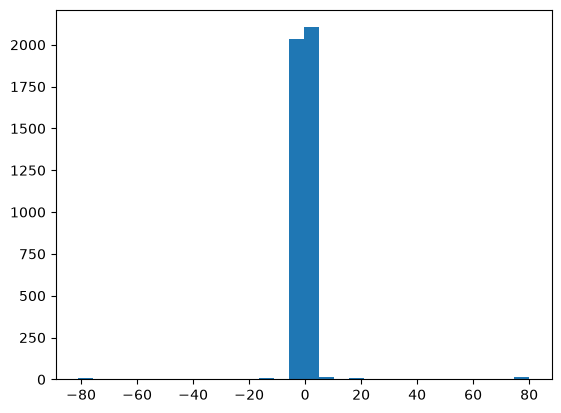

In [31]:
plt.hist(dif_cad_df['dif_cad'], bins=30)
plt.show()

In [32]:
# cadence sometimes can record single-foot movements, instead of double-foot movements, which is why we see some cadence values that are half of the other cadence values. 
# For example, if one source records 80 cadence and the other records 40 cadence, it could be due to one source counting each foot strike (double) and the other counting each individual foot strike (single).    
# Let's create a new column named scaled_cadence that will scale the cadence values accordingly: double the cadence values if Cadence is around double values of cadence.

is_half = (df['Cadence'] / df['cadence']).between(1.8, 2.2)
df['cadence_scaled'] = np.where(is_half, df['cadence'] * 2, df['cadence'])


In [33]:
# We will create a unified cadence column that will prioritize Cadence if it is present, otherwise it will use scaled_cadence if it is present.
# Then fill N/A values with 0 for unified cadence. There should be only 22 rows of N/A values before fillna.

df['cadence_unified'] = df['Cadence'].fillna(df['cadence_scaled'])
df['cadence_unified'] = df['cadence_unified'].fillna(0)
df.sample(5)

,Air Power,Cadence,Form Power,Ground Time,Leg Spring Stiffness,Power,Vertical Oscillation,altitude,cadence,datafile,distance,enhanced_altitude,enhanced_speed,fractional_cadence,heart_rate,position_lat,position_long,speed,timestamp,unknown_87,unknown_88,unknown_90,timestamp_dt,cadence_scaled,cadence_unified
15785,1.0,80.0,97.0,330.0,13.125,357.0,5.875,NaN,80.0,activities/2786247269.fit.gz,2341.99,305.4,2.482,0.0,165.0,504516087.0,-1.005555e+09,NaN,2019-08-17 12:04:51,0.0,300.0,0.0,2019-08-17 12:04:51,80.0,80.0
39236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.0,activities/2917827233.fit.gz,36144.56,243.4,3.294,0.0,NaN,504672431.0,-9.991486e+08,NaN,2019-09-30 22:54:29,0.0,NaN,NaN,2019-09-30 22:54:29,84.0,84.0
19809,1.0,79.0,103.0,328.0,12.750,306.0,6.625,NaN,78.0,activities/2796644542.fit.gz,4899.23,223.2,2.501,0.0,148.0,504380298.0,-9.985372e+08,NaN,2019-08-20 19:52:20,0.0,300.0,1.0,2019-08-20 19:52:20,78.0,79.0
37294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,activities/2904156632.fit.gz,6232.61,253.6,7.343,0.0,145.0,504854610.0,-9.994723e+08,NaN,2019-09-25 22:01:48,0.0,300.0,NaN,2019-09-25 22:01:48,11.0,11.0
36205,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.0,activities/2898932854.fit.gz,5632.80,270.6,12.307,0.0,140.0,504780031.0,-9.995511e+08,NaN,2019-09-23 21:13:24,0.0,300.0,NaN,2019-09-23 21:13:24,68.0,68.0


In [34]:
df['cadence_unified'].describe()

count    40649.000000
mean        72.729883
std         17.835318
min          0.000000
25%         74.000000
50%         78.000000
75%         80.000000
max        118.000000
Name: cadence_unified, dtype: float64

In [35]:
df.isna().sum()

Air Power               22807
Cadence                 22802
Form Power              22807
Ground Time             22802
Leg Spring Stiffness    22807
Power                   22802
Vertical Oscillation    22802
altitude                25744
cadence                    22
datafile                    0
distance                    0
enhanced_altitude          51
enhanced_speed             10
fractional_cadence         22
heart_rate               2294
position_lat              192
position_long             192
speed                   25721
timestamp                   0
unknown_87                 22
unknown_88               2294
unknown_90              22031
timestamp_dt                0
cadence_scaled             22
cadence_unified             0
dtype: int64

In [36]:
# Let's explore heart rate

hr_cleaned = df[df['heart_rate'].notna()]
hr_cleaned.describe()

,Air Power,Cadence,Form Power,Ground Time,Leg Spring Stiffness,Power,Vertical Oscillation,altitude,cadence,distance,enhanced_altitude,enhanced_speed,fractional_cadence,heart_rate,position_lat,position_long,speed,unknown_87,unknown_88,unknown_90,timestamp_dt,cadence_scaled,cadence_unified
count,17842.000000,17847.000000,17842.000000,17847.000000,17842.000000,17847.000000,17847.000000,14905.000000,38344.000000,38355.000000,38304.000000,38345.000000,38344.000000,38355.000000,3.816300e+04,3.816300e+04,14928.000000,38344.0,38355.000000,18618.000000,38355,38344.000000,38355.000000
mean,1.872100,77.726565,99.485932,325.934107,13.138571,301.459797,6.458074,3846.184368,73.867672,3641.014081,272.072144,2.854132,0.074314,134.680094,5.045379e+08,-9.995210e+08,2067.483856,0.0,298.513883,-1.067354,2019-08-16 12:43:20.065988,73.867672,73.833790
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3555.000000,0.000000,0.000000,209.000000,0.000000,0.000000,56.000000,5.039995e+08,-1.005696e+09,0.000000,0.0,100.000000,-13.000000,2019-07-08 21:04:03,0.000000,0.000000
25%,1.000000,78.000000,97.000000,308.000000,13.000000,283.000000,6.125000,3768.000000,75.000000,1083.475000,253.400000,2.090000,0.000000,121.000000,5.044413e+08,-9.993970e+08,1782.000000,0.0,300.000000,-3.000000,2019-07-30 19:39:24,75.000000,75.000000
50%,1.000000,79.000000,101.000000,326.000000,13.375000,303.000000,6.500000,3829.000000,78.000000,2333.480000,270.400000,2.417000,0.000000,136.000000,5.045103e+08,-9.992602e+08,2071.000000,0.0,300.000000,0.000000,2019-08-20 19:41:48,78.000000,78.000000
75%,2.000000,80.000000,105.000000,340.000000,13.750000,326.000000,7.000000,3912.000000,80.000000,4199.930000,292.000000,2.734000,0.000000,148.000000,5.046140e+08,-9.990522e+08,2370.000000,0.0,300.000000,0.000000,2019-08-23 02:04:57.500000,80.000000,80.000000
max,48.000000,88.000000,125.000000,1732.000000,16.875000,462.000000,12.500000,5043.000000,117.000000,38652.590000,508.600000,15.237000,0.500000,183.000000,5.089272e+08,-9.921938e+08,7744.000000,0.0,300.000000,6.000000,2019-10-03 23:05:05,117.000000,117.000000
std,2.777476,9.202077,13.866222,71.773687,2.039567,48.540552,1.135497,134.262498,16.084253,4931.337724,25.247229,1.745879,0.177863,18.713782,1.538676e+05,1.409369e+06,527.173476,0.0,17.176218,2.820492,NaN,16.084253,16.149888


In [38]:
pd.set_option('display.max_rows', None)
hr_cleaned[['heart_rate', 'cadence_unified', 'timestamp_dt']].head(10)

,heart_rate,cadence_unified,timestamp_dt
0,68.0,0.0,2019-07-08 21:04:03
1,68.0,0.0,2019-07-08 21:04:04
2,71.0,54.0,2019-07-08 21:04:07
3,77.0,77.0,2019-07-08 21:04:14
4,80.0,77.0,2019-07-08 21:04:15
5,83.0,77.0,2019-07-08 21:04:16
6,83.0,77.0,2019-07-08 21:04:17
7,86.0,77.0,2019-07-08 21:04:18
8,90.0,74.0,2019-07-08 21:04:20
9,92.0,74.0,2019-07-08 21:04:22


Too many data points due to new recording every few seconds. It is better to reduce to average heart rate and cadence value every workout session. In our definition, if a workout record is more than 30 minutes away from the last record, it is a new workout session.

In [39]:
hr_sorted = hr_cleaned.sort_values(by='timestamp_dt').drop_duplicates(subset=['timestamp_dt'])
hr_sorted.head()

,Air Power,Cadence,Form Power,Ground Time,Leg Spring Stiffness,Power,Vertical Oscillation,altitude,cadence,datafile,distance,enhanced_altitude,enhanced_speed,fractional_cadence,heart_rate,position_lat,position_long,speed,timestamp,unknown_87,unknown_88,unknown_90,timestamp_dt,cadence_scaled,cadence_unified
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,activities/2675855419.fit.gz,0.00,NaN,0.000,0.0,68.0,NaN,NaN,0.0,2019-07-08 21:04:03,0.0,300.0,NaN,2019-07-08 21:04:03,0.0,0.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,activities/2675855419.fit.gz,0.00,NaN,0.000,0.0,68.0,NaN,NaN,0.0,2019-07-08 21:04:04,0.0,300.0,NaN,2019-07-08 21:04:04,0.0,0.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.0,activities/2675855419.fit.gz,1.32,NaN,1.316,0.0,71.0,NaN,NaN,1316.0,2019-07-08 21:04:07,0.0,300.0,NaN,2019-07-08 21:04:07,54.0,54.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3747.0,77.0,activities/2675855419.fit.gz,12.19,249.4,1.866,0.0,77.0,504432050.0,-999063637.0,1866.0,2019-07-08 21:04:14,0.0,100.0,NaN,2019-07-08 21:04:14,77.0,77.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3798.0,77.0,activities/2675855419.fit.gz,14.08,259.6,1.894,0.0,80.0,504432492.0,-999064534.0,1894.0,2019-07-08 21:04:15,0.0,100.0,NaN,2019-07-08 21:04:15,77.0,77.0


In [40]:
hr_sorted.timestamp_dt.describe()

count                         38355
mean     2019-08-16 12:43:20.065988
min             2019-07-08 21:04:03
25%             2019-07-30 19:39:24
50%             2019-08-20 19:41:48
75%      2019-08-23 02:04:57.500000
max             2019-10-03 23:05:05
Name: timestamp_dt, dtype: object

In [41]:
time_deltas = hr_sorted['timestamp_dt'].diff().dt.total_seconds()
hr_sorted['session_id'] = (time_deltas >= 1800).cumsum()
workout_summary = hr_sorted.groupby('session_id').agg(
    start_time=('timestamp_dt', 'min'),
    end_time=('timestamp_dt', 'max'),
    avg_heart_rate=('heart_rate', 'mean'),
    avg_cadence=('cadence_unified', 'mean')
).reset_index(drop=True)

print(workout_summary)

            start_time            end_time  avg_heart_rate  avg_cadence
0  2019-07-08 21:04:03 2019-07-08 21:23:55      118.337398    74.406504
1  2019-07-10 23:18:00 2019-07-10 23:37:20      130.123596    79.314607
2  2019-07-12 21:27:11 2019-07-12 22:30:17      117.687157    74.135016
3  2019-07-14 17:20:28 2019-07-14 18:38:22      110.975460    74.465381
4  2019-07-14 20:45:07 2019-07-14 21:04:51      123.819398    79.705686
5  2019-07-16 21:10:40 2019-07-16 21:29:10      118.858824    76.100000
6  2019-07-17 23:17:06 2019-07-18 00:42:16      128.251504    74.731649
7  2019-07-18 20:47:54 2019-07-18 21:37:03      109.853125    65.135937
8  2019-07-20 14:56:40 2019-07-20 15:56:14      107.839321    73.717565
9  2019-07-20 21:28:37 2019-07-20 21:50:14      109.905660    77.018868
10 2019-07-21 21:58:25 2019-07-21 22:16:30      129.340659    80.347985
11 2019-07-22 21:47:17 2019-07-22 22:05:46      129.774306    79.111111
12 2019-07-23 00:49:07 2019-07-23 01:14:46      129.789773    77

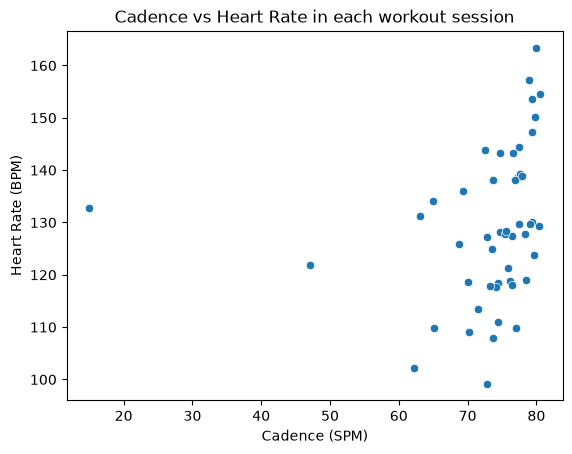

In [42]:
sns.scatterplot(data=workout_summary, x="avg_cadence", y="avg_heart_rate")
plt.title("Cadence vs Heart Rate in each workout session")
plt.xlabel("Cadence (SPM)")
plt.ylabel("Heart Rate (BPM)")
plt.show()

In [43]:
workout_summary['duration(m)'] = (workout_summary['end_time'] - workout_summary['start_time']).dt.total_seconds() / 60  # duration in minutes
workout_summary.head()

,start_time,end_time,avg_heart_rate,avg_cadence,duration(m)
0,2019-07-08 21:04:03,2019-07-08 21:23:55,118.337398,74.406504,19.866667
1,2019-07-10 23:18:00,2019-07-10 23:37:20,130.123596,79.314607,19.333333
2,2019-07-12 21:27:11,2019-07-12 22:30:17,117.687157,74.135016,63.100000
3,2019-07-14 17:20:28,2019-07-14 18:38:22,110.975460,74.465381,77.900000
4,2019-07-14 20:45:07,2019-07-14 21:04:51,123.819398,79.705686,19.733333


In [44]:
workout_summary.describe()

,start_time,end_time,avg_heart_rate,avg_cadence,duration(m)
count,49,49,49.000000,49.000000,49.000000
mean,2019-08-10 05:51:51.142857,2019-08-10 06:31:36.775510,129.029087,73.048548,39.760544
min,2019-07-08 21:04:03,2019-07-08 21:23:55,99.187675,14.988456,7.466667
25%,2019-07-23 00:49:07,2019-07-23 01:14:46,118.566787,72.811688,19.333333
50%,2019-08-05 21:45:11,2019-08-05 22:03:00,128.251504,75.614407,33.216667
75%,2019-08-21 01:15:54,2019-08-21 01:49:07,138.466667,77.936271,49.150000
max,2019-10-03 21:30:03,2019-10-03 23:05:05,163.401752,80.532511,95.033333
std,NaN,NaN,14.553232,10.355174,24.769623


Let's remove two outliers on the far left.

In [45]:
workout_summary_cleaned = workout_summary[workout_summary['avg_cadence'] > 50]

In [46]:
workout_summary_cleaned.describe()

,start_time,end_time,avg_heart_rate,avg_cadence,duration(m)
count,47,47,47.000000,47.000000,47.000000
mean,2019-08-08 13:18:29.382978,2019-08-08 13:58:10.234042,129.101145,74.835715,39.680851
min,2019-07-08 21:04:03,2019-07-08 21:23:55,99.187675,62.141593,7.466667
25%,2019-07-22 23:18:12,2019-07-22 23:40:16,118.452093,73.031237,19.183333
50%,2019-08-04 20:03:36,2019-08-04 21:26:19,128.251504,75.922330,32.533333
75%,2019-08-20 19:55:42,2019-08-20 20:33:17,138.714057,78.131772,54.358333
max,2019-10-03 21:30:03,2019-10-03 23:05:05,163.401752,80.532511,95.033333
std,NaN,NaN,14.818461,4.552149,25.270632


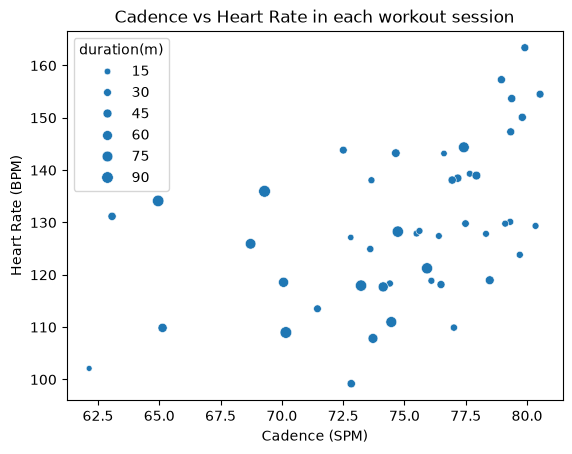

In [47]:
sns.scatterplot(data=workout_summary_cleaned, x='avg_cadence', y='avg_heart_rate', size='duration(m)')
plt.title("Cadence vs Heart Rate in each workout session")
plt.xlabel("Cadence (SPM)")
plt.ylabel("Heart Rate (BPM)")
plt.show()

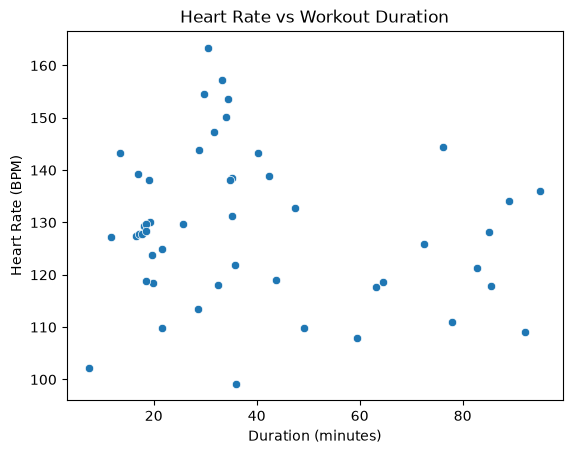

In [48]:
sns.scatterplot(data=workout_summary, x='duration(m)', y='avg_heart_rate')
plt.title("Heart Rate vs Workout Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Heart Rate (BPM)")
plt.show()

Next, we will see how many times did Chris workout each day. Then create a heat map based on this. We are also interested in which days of the week Chris tend to work out the most consistently.

In [49]:
workout_summary['date'] = workout_summary['start_time'].dt.date
workout_summary['day_of_week'] = workout_summary['start_time'].dt.day_name()
workout_summary.head()

,start_time,end_time,avg_heart_rate,avg_cadence,duration(m),date,day_of_week
0,2019-07-08 21:04:03,2019-07-08 21:23:55,118.337398,74.406504,19.866667,2019-07-08,Monday
1,2019-07-10 23:18:00,2019-07-10 23:37:20,130.123596,79.314607,19.333333,2019-07-10,Wednesday
2,2019-07-12 21:27:11,2019-07-12 22:30:17,117.687157,74.135016,63.100000,2019-07-12,Friday
3,2019-07-14 17:20:28,2019-07-14 18:38:22,110.975460,74.465381,77.900000,2019-07-14,Sunday
4,2019-07-14 20:45:07,2019-07-14 21:04:51,123.819398,79.705686,19.733333,2019-07-14,Sunday


In [50]:
type(workout_summary['start_time'].iloc[0])

pandas.Timestamp

In [51]:
len(workout_summary['date'].unique())

45

In [52]:
daily_session_count = workout_summary.groupby('date').size().reset_index(name='daily_session_count')
daily_session_count.head()

,date,daily_session_count
0,2019-07-08,1
1,2019-07-10,1
2,2019-07-12,1
3,2019-07-14,2
4,2019-07-16,1


In [53]:
daily_session_count.describe()

,daily_session_count
count,45.000000
mean,1.088889
std,0.287799
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,2.000000


In [54]:
full_date_range = pd.date_range(start=df['timestamp_dt'].min(), end=df['timestamp_dt'].max())


In [55]:
df_calendar = pd.DataFrame({'date': full_date_range.date})
session_map = daily_session_count.set_index('date')['daily_session_count']
df_calendar['session_count'] = df_calendar['date'].map(session_map).fillna(0)  
df_calendar.head()

,date,session_count
0,2019-07-08,1.0
1,2019-07-09,0.0
2,2019-07-10,1.0
3,2019-07-11,0.0
4,2019-07-12,1.0


In [56]:
type(df_calendar['date'].iloc[0])

datetime.date

In [57]:
df_calendar['session_count'] = df_calendar['session_count'].astype(int)
df_calendar.head()

,date,session_count
0,2019-07-08,1
1,2019-07-09,0
2,2019-07-10,1
3,2019-07-11,0
4,2019-07-12,1


In [58]:
type(df_calendar['session_count'].iloc[0])

numpy.int64

In [59]:
df_calendar['datetime'] = pd.to_datetime(df_calendar['date'])
df_calendar['day_of_week'] = df_calendar['datetime'].dt.day_name()
df_calendar.head()

,date,session_count,datetime,day_of_week
0,2019-07-08,1,2019-07-08,Monday
1,2019-07-09,0,2019-07-09,Tuesday
2,2019-07-10,1,2019-07-10,Wednesday
3,2019-07-11,0,2019-07-11,Thursday
4,2019-07-12,1,2019-07-12,Friday


In [60]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [61]:
df_calendar['week_start'] = df_calendar['datetime'].dt.to_period('W-MON').dt.start_time
df_calendar.head()

,date,session_count,datetime,day_of_week,week_start
0,2019-07-08,1,2019-07-08,Monday,2019-07-02
1,2019-07-09,0,2019-07-09,Tuesday,2019-07-09
2,2019-07-10,1,2019-07-10,Wednesday,2019-07-09
3,2019-07-11,0,2019-07-11,Thursday,2019-07-09
4,2019-07-12,1,2019-07-12,Friday,2019-07-09


In [62]:
df_calendar['week_start_str'] = df_calendar['week_start'].dt.strftime('%b %d')
df_calendar.head()

,date,session_count,datetime,day_of_week,week_start,week_start_str
0,2019-07-08,1,2019-07-08,Monday,2019-07-02,Jul 02
1,2019-07-09,0,2019-07-09,Tuesday,2019-07-09,Jul 09
2,2019-07-10,1,2019-07-10,Wednesday,2019-07-09,Jul 09
3,2019-07-11,0,2019-07-11,Thursday,2019-07-09,Jul 09
4,2019-07-12,1,2019-07-12,Friday,2019-07-09,Jul 09


In [63]:
heatmap_matrix = (
    df_calendar.pivot_table(
        index='day_of_week',
        columns='week_start',
        values='session_count',
        aggfunc='sum',
        fill_value=0,
    )
    .reindex(day_order)
    .astype(int)
)

heatmap_matrix = heatmap_matrix.reindex(columns=sorted(heatmap_matrix.columns))
heatmap_matrix.columns = heatmap_matrix.columns.strftime('%b %d')
heatmap_matrix

week_start,Jul 02,Jul 09,Jul 16,Jul 23,Jul 30,Aug 06,Aug 13,Aug 20,Aug 27,Sep 03,Sep 10,Sep 17,Sep 24,Oct 01
day_of_week,,,,,,,,,,,,,,
Monday,1,0,1,1,1,1,0,0,0,0,1,1,0,0
Tuesday,0,0,1,1,1,1,0,2,0,0,0,0,0,0
Wednesday,0,1,1,1,1,1,1,2,1,0,0,0,1,0
Thursday,0,0,1,0,1,0,0,0,0,0,1,0,0,1
Friday,0,1,0,1,1,1,0,1,0,0,0,0,0,0
Saturday,0,0,2,1,1,1,1,1,1,0,1,0,1,0
Sunday,0,2,1,1,1,1,1,0,0,0,0,0,0,0


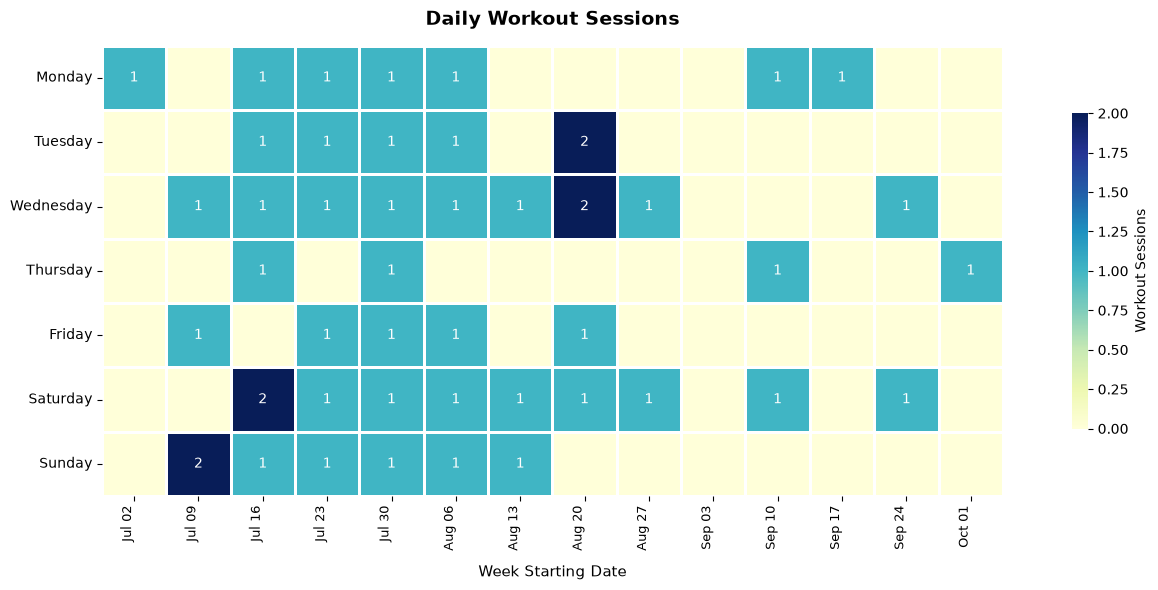

In [64]:
plt.figure(figsize=(15, 6))
ax = sns.heatmap(
    heatmap_matrix,
    cmap = 'YlGnBu',
    linewidths = 2,
    linecolor = 'white',
    square = True,
    cbar_kws = {'label': 'Workout Sessions', 'shrink': 0.7},
    annot = heatmap_matrix.map(lambda v: '' if v == 0 else str(int(v))), # skip annotation if workout session = 0
    fmt = '',
)

plt.title(
    'Daily Workout Sessions', 
    fontsize = 14, 
    pad = 15, 
    fontweight = 'bold'
)
plt.xlabel('Week Starting Date', fontsize=11, labelpad=10)
plt.ylabel('')
plt.yticks(rotation=0)
plt.xticks(rotation=90, ha='right', fontsize=9)  

plt.tight_layout()
plt.show()

Next, let's look into daily duration of workout sessions. We will then plot a bar chart visualizing these workout durations.

In [65]:
duration_df = workout_summary.groupby('date')['duration(m)'].sum().reset_index(name='daily_duration(m)')
duration_df.head()

,date,daily_duration(m)
0,2019-07-08,19.866667
1,2019-07-10,19.333333
2,2019-07-12,63.100000
3,2019-07-14,97.633333
4,2019-07-16,18.500000


In [66]:
duration_df['day_of_week'] = pd.to_datetime(duration_df['date']).dt.day_name()
duration_df.head()

,date,daily_duration(m),day_of_week
0,2019-07-08,19.866667,Monday
1,2019-07-10,19.333333,Wednesday
2,2019-07-12,63.100000,Friday
3,2019-07-14,97.633333,Sunday
4,2019-07-16,18.500000,Tuesday


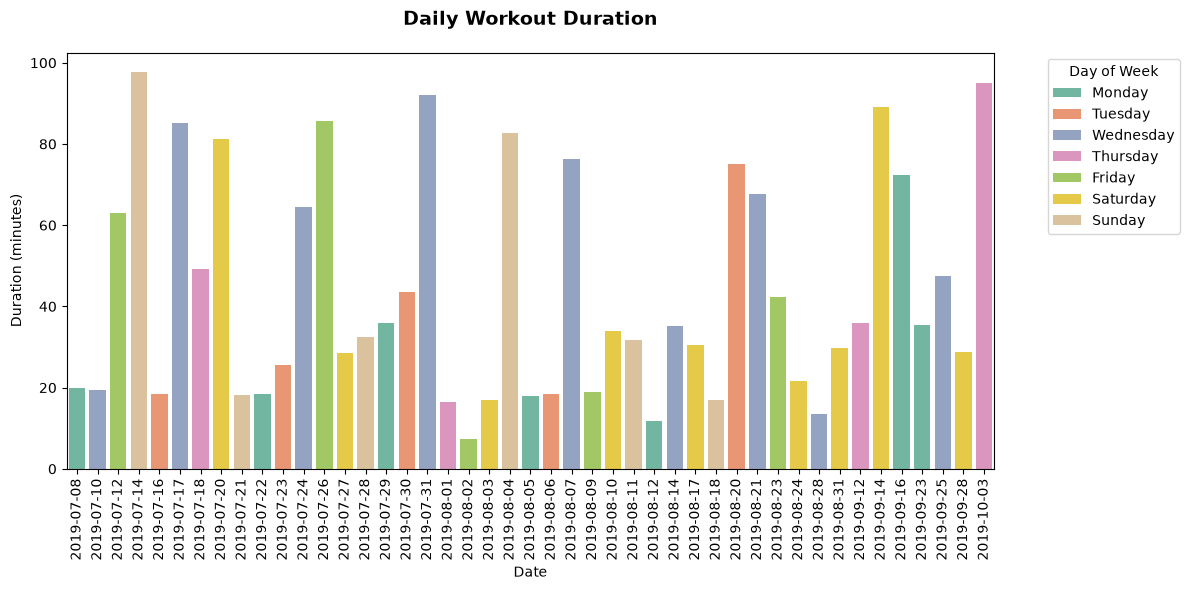

In [67]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=duration_df, 
    x='date', 
    y='daily_duration(m)',
    hue='day_of_week',
    hue_order = day_order,
    palette='Set2'
)

plt.title('Daily Workout Duration', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Date')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=90)
plt.legend(title='Day of Week', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()  

Next, we will create a 3D scatter plot to visualize the relationship between heart rate and geographic coordinates.

In [68]:
df.columns

Index(['Air Power', 'Cadence', 'Form Power', 'Ground Time',
       'Leg Spring Stiffness', 'Power', 'Vertical Oscillation', 'altitude',
       'cadence', 'datafile', 'distance', 'enhanced_altitude',
       'enhanced_speed', 'fractional_cadence', 'heart_rate', 'position_lat',
       'position_long', 'speed', 'timestamp', 'unknown_87', 'unknown_88',
       'unknown_90', 'timestamp_dt', 'cadence_scaled', 'cadence_unified'],
      dtype='str')

In [69]:
df['unified_altitude'] = df['enhanced_altitude'].fillna(df['altitude'])

In [70]:
df_selected = df[['heart_rate', 'unified_altitude', 'position_lat', 'position_long']]
df_selected.head()

,heart_rate,unified_altitude,position_lat,position_long
0,68.0,NaN,NaN,NaN
1,68.0,NaN,NaN,NaN
2,71.0,NaN,NaN,NaN
3,77.0,249.4,504432050.0,-999063637.0
4,80.0,259.6,504432492.0,-999064534.0


In [71]:
df_selected.describe()

,heart_rate,unified_altitude,position_lat,position_long
count,38355.000000,40598.000000,4.045700e+04,4.045700e+04
mean,134.680094,271.346027,5.045408e+08,-9.995175e+08
std,18.713782,25.035768,1.690905e+05,1.376341e+06
min,56.000000,209.000000,5.039868e+08,-1.005696e+09
25%,121.000000,252.800000,5.044397e+08,-9.993986e+08
50%,136.000000,269.200000,5.045116e+08,-9.992608e+08
75%,148.000000,291.200000,5.046159e+08,-9.990579e+08
max,183.000000,508.600000,5.089272e+08,-9.921938e+08


In [72]:
df_selected.isna().sum()

heart_rate          2294
unified_altitude      51
position_lat         192
position_long        192
dtype: int64

In [73]:
df_selected.shape

(40649, 4)

In [74]:
df_selected = df_selected.dropna()
df_selected.shape

(38163, 4)

In [75]:
df_selected.isna().sum()

heart_rate          0
unified_altitude    0
position_lat        0
position_long       0
dtype: int64

In [76]:
# Convert longitude and latitude to decimal degrees
df_selected['position_lat'] = df_selected['position_lat'] * (180 / 2**31)
df_selected['position_long'] = df_selected['position_long'] * (180 / 2**31)

In [77]:
df_selected.sample(5)

,heart_rate,unified_altitude,position_lat,position_long
24501,140.0,297.0,42.297660,-83.765900
24040,161.0,302.6,42.296867,-83.769323
19705,146.0,235.4,42.276436,-83.699040
7964,119.0,236.0,42.275948,-83.700780
6302,85.0,268.2,42.290908,-83.761573


In [78]:
df_selected.describe()

,heart_rate,unified_altitude,position_lat,position_long
count,38163.000000,38163.000000,38163.000000,38163.000000
mean,134.774415,272.084606,42.289875,-83.778882
std,18.670995,25.199153,0.012897,0.118132
min,56.000000,209.000000,42.244748,-84.296446
25%,121.000000,253.400000,42.281778,-83.768493
50%,137.000000,270.400000,42.287562,-83.757025
75%,148.000000,292.000000,42.296259,-83.739591
max,183.000000,508.600000,42.657785,-83.164726


In [79]:
# Convert global coordinates to flat coordinates using Mercantor projection

def lat2y(a):
    return 180.0/np.pi*np.log(np.tan(np.pi/4.0+a*(np.pi/180.0)/2.0))

df_selected["position_lat"]=df_selected["position_lat"].apply(lat2y)

In [80]:
df_selected.sample(5)

,heart_rate,unified_altitude,position_lat,position_long
568,119.0,246.4,46.744443,-83.751987
10901,131.0,269.4,46.751547,-83.758255
37949,143.0,237.6,46.754610,-83.747185
5404,111.0,250.0,46.741517,-83.742910
10196,113.0,250.8,46.716522,-83.732298


In [81]:
df_selected.describe()

,heart_rate,unified_altitude,position_lat,position_long
count,38163.000000,38163.000000,38163.000000,38163.000000
mean,134.774415,272.084606,46.752828,-83.778882
std,18.670995,25.199153,0.017438,0.118132
min,56.000000,209.000000,46.691845,-84.296446
25%,121.000000,253.400000,46.741880,-83.768493
50%,137.000000,270.400000,46.749698,-83.757025
75%,148.000000,292.000000,46.761455,-83.739591
max,183.000000,508.600000,47.251630,-83.164726


Text(0.5, 0, 'Altitude')

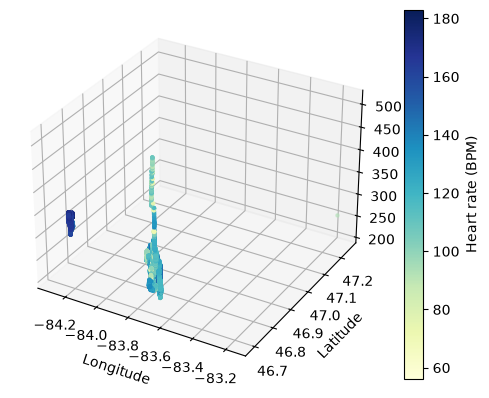

In [82]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

artists = ax.scatter(
    df_selected['position_long'], 
    df_selected['position_lat'], 
    df_selected['unified_altitude'], 
    s = 5,
    c = df_selected['heart_rate'],
    cmap = 'YlGnBu'
)

plt.colorbar(artists).set_label('Heart rate (BPM)')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Altitude')

# We'll make this chart animated. So we can see better details of this chart from different angles.

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Now we define an initializeation function which will render the initial image, and return a set of Artists
# to render
def init():
    ax.scatter(df_selected['position_long'], df_selected['position_lat'], df_selected['unified_altitude'])
    return ax.get_children()

def update_view(frame):
    ax.view_init(30, frame)
    return ax.get_children()

from matplotlib import animation

anim = animation.FuncAnimation(
    fig,
    update_view,
    init_func = init,
    frames = [x for x in range(0, 360, 3)],
    interval = 20
)

from IPython.display import HTML
HTML(anim.to_jshtml())